In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import mode

In [ ]:
# 1. Use an in-built dataset
data = load_iris()
X = data.data
y_true = data.target
labels = data.target_names

In [ ]:
# Preprocessing (Feature Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 2. Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=3,covariance_type='full',random_state=42)
gmm.fit(X_scaled)

GaussianMixture(n_components=3, random_state=42)

In [ ]:
# Predict clusters
y_pred = gmm.predict(X_scaled)

In [ ]:
# Map clusters to actual labels (for evaluation)
mapped_labels = np.zeros_like(y_pred)

for i in range(3):
    mask = (y_pred == i)
    mapped_labels[mask] = mode(y_true[mask], keepdims=True)[0]

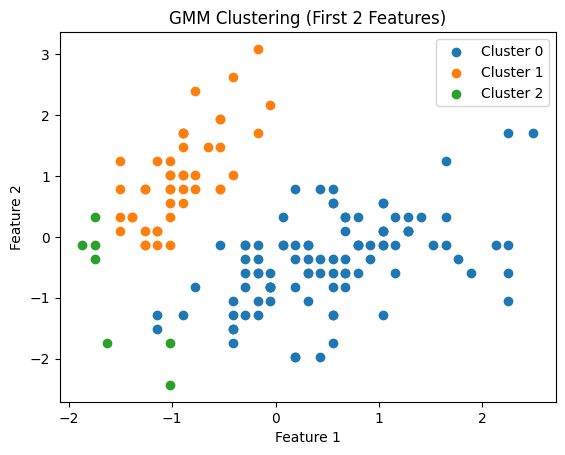

In [ ]:
# 3. Visualize cluster results
plt.figure()

for i in range(3):
    plt.scatter(
        X_scaled[y_pred == i, 0],
        X_scaled[y_pred == i, 1],
        label=f"Cluster {i}"
    )

plt.title("GMM Clustering (First 2 Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

Accuracy: 0.6666666666666666


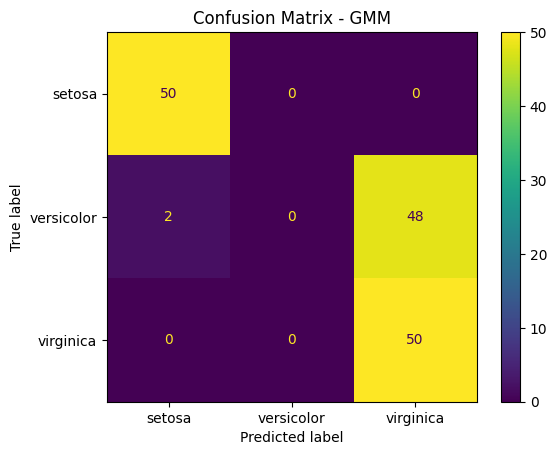

In [ ]:
# 4. Model Evaluation
accuracy = accuracy_score(y_true, mapped_labels)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_true, mapped_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix - GMM")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_pred)

print("Silhouette Score:", score)

Silhouette Score: 0.4751434694267145


In [ ]:
print("Log Likelihood:", gmm.score(X_scaled))

Log Likelihood: -2.069075321188533


In [ ]:
# 5. Probability predictions for outcome
probs = gmm.predict_proba(X_scaled)

print("\n--- Probability Predictions ---")
print("First 5 samples:")
print(probs[:5])

print("\nInterpretation Example:")
print("Sample 1 probabilities:", probs[0])


--- Probability Predictions ---
First 5 samples:
[[2.74503381e-011 1.00000000e+000 0.00000000e+000]
 [1.16033052e-007 9.99999884e-001 0.00000000e+000]
 [9.72921434e-009 9.99999990e-001 5.88168010e-278]
 [2.02193473e-007 9.99999798e-001 3.33173699e-141]
 [9.67775891e-012 1.00000000e+000 0.00000000e+000]]

Interpretation Example:
Sample 1 probabilities: [2.74503381e-11 1.00000000e+00 0.00000000e+00]


In [ ]:
# 6. Cluster Means
print("\n--- Cluster Means ---")
print(gmm.means_)


--- Cluster Means ---
[[ 0.53745909 -0.39369142  0.6693573   0.64500292]
 [-0.93852253  0.98617415 -1.29410958 -1.24871335]
 [-1.53616188 -0.9148767  -1.05760659 -1.00758605]]


In [ ]:
# 7. Cluster Covariances
print("\n--- Cluster Covariances ---")
print(gmm.covariances_)


--- Cluster Covariances ---
[[[ 0.6041439   0.29261198  0.28890501  0.24177881]
  [ 0.29261198  0.53389164  0.16028899  0.21491843]
  [ 0.28890501  0.16028899  0.207522    0.2027757 ]
  [ 0.24177881  0.21491843  0.2027757   0.29967967]]

 [[ 0.13510948  0.19602161  0.00308347  0.01212811]
  [ 0.19602161  0.58216106  0.0018129   0.02637945]
  [ 0.00308347  0.0018129   0.00895969  0.00387616]
  [ 0.01212811  0.02637945  0.00387616  0.01965801]]

 [[ 0.1132855  -0.27943484  0.18318977  0.16256471]
  [-0.27943484  0.97422493 -0.42626817 -0.39428536]
  [ 0.18318977 -0.42626817  0.30445233  0.26469844]
  [ 0.16256471 -0.39428536  0.26469844  0.23383281]]]
